# Depression — Fig. 5 A–D
Reproduce the C12L-T4 healthy / X40L-T4 depression bin100 comparison.
A is recalculated from measured expression. B–D use the completed 4,882-gene KO/OE and regulon screens; rankings, reciprocal-target fractions, and the five-TF network are recalculated from those tables.
The scan plots summarize model responses toward the healthy centroid. They are within-pair perturbation results.

In [1]:
from pathlib import Path
import sys, os
ROOT = Path("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main")
TUTORIAL = ROOT / "tutorial"
FRAMEWORK = TUTORIAL / "_framework/BrainBeacon"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(FRAMEWORK))
from brainbeacon.configs.config import DEFAULT_PATHS
DEFAULT_PATHS.update({
    "BASE_DIR": str(ROOT), "PRIOR_DIR": str(ROOT / "prior_knowledge"),
    "PRETRAIN_DIR": str(ROOT / "pretrained"),
    "GENE_DICT_PATH": str(ROOT / "prior_knowledge/gene_dict.h5ad"),
    "GENE_LOOKUP_DIR": str(ROOT / "prior_knowledge/gene_lookup"),
    "ESM_EMBED_PATH": str(ROOT / "prior_knowledge/esm2_embeddings_d5120.pt"),
})

In [2]:
import gc
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from IPython.display import display
from brainbeacon.pipeline.cell_embedding import run_brainbeacon_pipeline
from brainbeacon.pipeline.perturbation import apply_gene_perturbation
plt.rcParams.update({"pdf.fonttype":42, "ps.fonttype":42, "svg.fonttype":"none", "font.size":10})
OUT_DIR = TUTORIAL / "outputs/fig5_depression"
FIG_DIR = TUTORIAL / "figures/fig5_depression"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
def save_panel(fig, stem):
    fig.tight_layout()
    for extension in ("pdf", "svg", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{extension}", dpi=300, bbox_inches="tight")
    plt.show()
HEALTHY_SLICE, DEPRESSION_SLICE, PAIR = "C12L-T4", "X40L-T4", "bin100"
HEALTHY_ADATA_PATH = ROOT / "data/depression_data/h5ad/C12L-T4.bin100.healthy.h5ad"
DEPRESSION_ADATA_PATH = ROOT / "data/depression_data/h5ad/X40L-T4.bin100.depression.h5ad"
gene_dict_path = ROOT / "prior_knowledge/gene_dict.h5ad"
SUMMARY_DIR = TUTORIAL / 'data/03_depression'
KO_TABLE = SUMMARY_DIR / "depression_bin100_gene_ko_clean_ranked.csv"
OE_TABLE = SUMMARY_DIR / "depression_bin100_gene_oe5x_clean_ranked.csv"
REGULON_TABLE = SUMMARY_DIR / "depression_bin100_regulon_ko_clean_ranked.csv"
PLP1_ENSEMBL, PLP1_GENE_SYMBOL = "ENSMUSG00000031425", "Plp1"
SOX10_REGULON_ID = "dorothea__Sox10"

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A. Measured Nrg3 expression

In [3]:
def build_mouse_symbol_map(gene_dict: ad.AnnData):
    """Build unique mouse symbol↔Ensembl maps from BrainBeacon gene_dict."""
    var = gene_dict.var.copy()
    mouse = var['species'].astype(str).str.lower().eq('mouse')
    var = var.loc[mouse].copy()
    var['gene_symbol'] = var['gene_symbol'].astype(str)
    counts = var['gene_symbol'].value_counts()
    var = var.loc[var['gene_symbol'].isin(counts[counts == 1].index)]
    symbol_to_ens = dict(zip(var['gene_symbol'], var.index.astype(str)))
    ens_to_symbol = dict(zip(var.index.astype(str), var['gene_symbol']))
    return (symbol_to_ens, ens_to_symbol)

def convert_symbols_to_ensembl(adata_input: ad.AnnData, symbol_to_ens):
    """Map a source AnnData gene-symbol axis to the BrainBeacon Ensembl axis."""
    adata_output = adata_input.copy()
    symbols = adata_output.var['gene_symbol'].astype(str) if 'gene_symbol' in adata_output.var else pd.Series(adata_output.var_names.astype(str), index=adata_output.var_names)
    ensembl = symbols.map(symbol_to_ens)
    keep = ensembl.notna().to_numpy()
    mapped = adata_output[:, keep].copy()
    mapped.var['gene_symbol'] = symbols[keep].to_numpy()
    mapped.var_names = ensembl[keep].astype(str).to_numpy()
    mapped.var_names_make_unique()
    return mapped

def prefix_obs_names(adata_input: ad.AnnData, prefix: str):
    adata_output = adata_input.copy()
    adata_output.obs_names = [f'{prefix}:{name}' for name in adata_output.obs_names.astype(str)]
    return adata_output
gene_dict = sc.read_h5ad(gene_dict_path)
(symbol_to_ens, ens_to_symbol) = build_mouse_symbol_map(gene_dict)
healthy_adata = sc.read_h5ad(HEALTHY_ADATA_PATH)
depression_adata = sc.read_h5ad(DEPRESSION_ADATA_PATH)
healthy_adata = convert_symbols_to_ensembl(healthy_adata, symbol_to_ens)
depression_adata = convert_symbols_to_ensembl(depression_adata, symbol_to_ens)
healthy_adata = prefix_obs_names(healthy_adata, HEALTHY_SLICE)
depression_adata = prefix_obs_names(depression_adata, DEPRESSION_SLICE)
healthy_adata.obs['condition'] = 'healthy'
depression_adata.obs['condition'] = 'depression'
healthy_adata.obs['slice'] = HEALTHY_SLICE
depression_adata.obs['slice'] = DEPRESSION_SLICE
healthy_adata.obs['cell_label'] = 'Healthy'
depression_adata.obs['cell_label'] = 'Depression'
adata_pair = ad.concat([healthy_adata, depression_adata], join='outer', fill_value=0, index_unique=None)
adata_pair.var = gene_dict.var.loc[adata_pair.var_names].copy()
adata_pair.var['gene_symbol'] = [ens_to_symbol.get(gene, str(gene)) for gene in adata_pair.var_names.astype(str)]
adata_pair.obs['region'] = PAIR
adata_pair.obs['brain_region'] = 'depression_pair'
adata_pair.obs['dataset'] = 'depression'
before_shape = adata_pair.shape
sc.pp.filter_cells(adata_pair, min_genes=3)
sc.pp.filter_genes(adata_pair, min_cells=3)
adata_pair.var = gene_dict.var.loc[adata_pair.var_names].copy()
adata_pair.var['gene_symbol'] = [ens_to_symbol.get(gene, str(gene)) for gene in adata_pair.var_names.astype(str)]
print(f'[QC] min_genes=3/min_cells=3: {before_shape} -> {adata_pair.shape}')
print('input pair:', adata_pair)
print('condition counts:', adata_pair.obs['condition'].value_counts().to_dict())
print('obsm keys:', list(adata_pair.obsm.keys()))
del healthy_adata, depression_adata, gene_dict
gc.collect()

[QC] min_genes=3/min_cells=3: (23788, 23769) -> (23784, 22224)
input pair: AnnData object with n_obs × n_vars = 23784 × 22224
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'binID', 'cellsize', 'x', 'y', 'MIDCount', 'ExonCount', 'dnbCount', 'detectGeneCount', 'secBinId', 'secId', 'percent.mt', 'countFeatureRatio', 'sampleId', 'sample_id', 'condition', 'bin_type', 'species', 'platform', 'slice', 'dataset', 'cell_label', 'region', 'brain_region', 'n_genes'
    var: 'gene_id', 'gene_symbol', 'species', 'homo_connect_id_old', 'homo_connect_id', 'gene_type', 'gene_type_id', 'esm_norm', 'has_esm', 'mean_merfish', 'mean_slideseqv2', 'mean_starmap', 'mean_stereo', 'mean_xenium', 'homo_esm_rnatype_group_size', 'not_unique_homo_esm_rnatype'
    obsm: 'spatial'
condition counts: {'healthy': 11929, 'depression': 11855}
obsm keys: ['spatial']


732

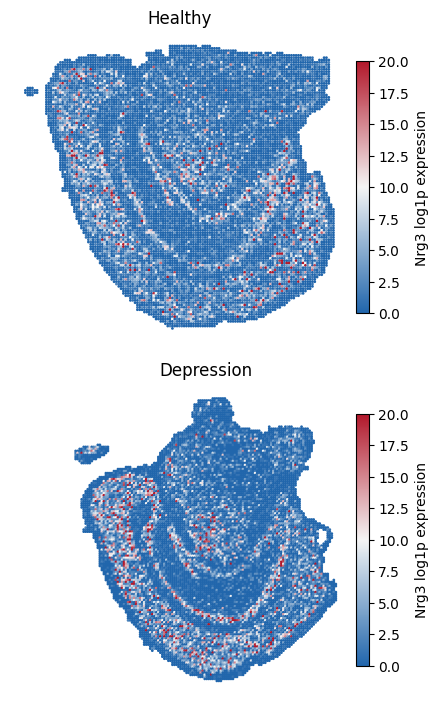

In [28]:
from matplotlib.colors import LinearSegmentedColormap
gene_id = adata_pair.var_names[adata_pair.var["gene_symbol"].eq("Nrg3")][0]
values = adata_pair[:, gene_id].X
values = values.toarray().ravel() if sparse.issparse(values) else np.asarray(values).ravel()
expression = np.log1p(np.clip(values, 0, None))
expression = values
vmax = 20
cmap = LinearSegmentedColormap.from_list("Nrg3_expression", ["#2166AC", "#F4F4F4", "#B2182B"])
fig, axes = plt.subplots(2, 1, figsize=(4.5, 7.2))
for ax, condition in zip(axes, ["healthy", "depression"]):
    mask = adata_pair.obs["condition"].eq(condition).to_numpy()
    xy = np.asarray(adata_pair.obsm["spatial"])[mask]
    dots = ax.scatter(xy[:,0], xy[:,1], c=expression[mask], s=4, cmap=cmap, vmin=0, vmax=vmax, linewidths=0, rasterized=True)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    ax.set_title(condition.capitalize())
    fig.colorbar(dots, ax=ax, fraction=.035, pad=.02, label="Nrg3 log1p expression")
save_panel(fig, "Fig5_A_Nrg3_expression")

## B/C. Gene KO/OE reciprocity and regulon responses

In [3]:
ko = pd.read_csv(KO_TABLE).set_index('gene_ensembl', drop=False)
oe = pd.read_csv(OE_TABLE).set_index('gene_ensembl', drop=False)
regulon = pd.read_csv(REGULON_TABLE)
gene_scan = ko[['gene_ensembl', 'gene_symbol', 'delta_cosine']].rename(columns={'delta_cosine': 'delta_gene_ko'}).join(oe[['delta_cosine', 'n_disease_cells_expressed']].rename(columns={'delta_cosine': 'delta_gene_oe5x', 'n_disease_cells_expressed': 'n_cells_expr_for_oe'}), how='inner')
gene_scan['ko_help_oe_harm'] = (gene_scan['delta_gene_ko'] > 0) & (gene_scan['delta_gene_oe5x'] < 0)
gene_scan['bidirectional_axis'] = gene_scan['delta_gene_ko'] - gene_scan['delta_gene_oe5x']
gene_scan = gene_scan.sort_values('bidirectional_axis', ascending=False)
gene_scan.to_csv(OUT_DIR / 'depression_cross_modal_gene_scan.csv', index=False)
reg_rows = []
for (_, row) in regulon.iterrows():
    targets = [gene for gene in str(row['target_ensembl_in_model']).split(';') if gene in gene_scan.index]
    target_scan = gene_scan.loc[targets] if targets else gene_scan.iloc[0:0]
    bidirectional = target_scan['ko_help_oe_harm']
    reg_rows.append({'regulon_id': row['regulon_id'], 'tf_symbol': row['tf_symbol'], 'collection': row['collection'], 'delta_regulon_ko': row['delta_cosine'], 'n_targets_in_pair': row['n_targets_in_pair'], 'n_targets_in_gene_scan': len(target_scan), 'n_bidirectional_targets': int(bidirectional.sum()), 'fraction_bidirectional_targets': float(bidirectional.mean()) if len(target_scan) else np.nan, 'median_target_gene_ko': float(target_scan['delta_gene_ko'].median()) if len(target_scan) else np.nan, 'median_target_gene_oe5x': float(target_scan['delta_gene_oe5x'].median()) if len(target_scan) else np.nan})
regulon_concordance = pd.DataFrame(reg_rows).sort_values('delta_regulon_ko', ascending=False)
regulon_concordance.to_csv(OUT_DIR / 'depression_regulon_target_concordance.csv', index=False)
plp1_row = gene_scan.loc[PLP1_ENSEMBL]
sox10_row = regulon.loc[regulon['regulon_id'].eq(SOX10_REGULON_ID)].iloc[0]
selected_summary = pd.DataFrame([{'intervention': 'Plp1 gene KO', 'level': 'gene', 'delta_cosine': plp1_row['delta_gene_ko'], 'interpretation': 'toward healthy centroid'}, {'intervention': 'Plp1 gene OE 5x', 'level': 'gene', 'delta_cosine': plp1_row['delta_gene_oe5x'], 'interpretation': 'away from healthy centroid'}, {'intervention': 'Sox10 regulon KO', 'level': 'regulon', 'delta_cosine': sox10_row['delta_cosine'], 'interpretation': 'toward healthy centroid'}])
selected_summary.to_csv(OUT_DIR / 'selected_plp1_sox10_scan_summary.csv', index=False)
display(selected_summary)
display(regulon_concordance[['regulon_id', 'delta_regulon_ko', 'n_targets_in_gene_scan', 'n_bidirectional_targets', 'fraction_bidirectional_targets']].head(12))

,intervention,level,delta_cosine,interpretation
0,Plp1 gene KO,gene,0.005770,toward healthy centroid
1,Plp1 gene OE 5x,gene,-0.004756,away from healthy centroid
2,Sox10 regulon KO,regulon,0.006288,toward healthy centroid


,regulon_id,delta_regulon_ko,n_targets_in_gene_scan,n_bidirectional_targets,fraction_bidirectional_targets
0,dorothea__Gata2,0.013384,105,58,0.552381
1,combined__Gata2,0.013323,110,59,0.536364
2,dorothea__Tal1,0.009462,74,39,0.527027
3,combined__Tal1,0.009421,78,39,0.500000
4,dorothea__Fos,0.007842,84,38,0.452381
5,dorothea__Mitf,0.007311,78,35,0.448718
6,dorothea__Sox10,0.006288,9,3,0.333333
7,combined__Sox10,0.006250,13,3,0.230769
8,trrust__Myc,0.005606,14,5,0.357143
9,trrust__Spi1,0.005123,20,6,0.300000


Genes satisfying KO ≥ +0.001 or OE ≤ −0.001: 47


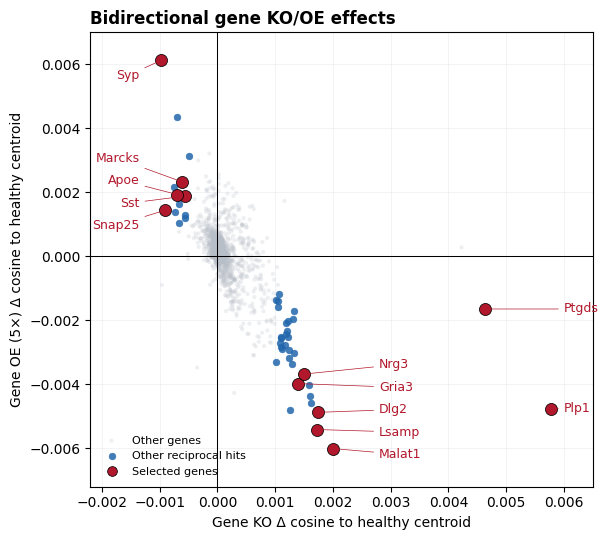

In [4]:
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba
from matplotlib.lines import Line2D
BLUE = '#2166AC'
RED = '#B2182B'
BACKGROUND = '#B8BEC7'
GRID = '#D9DDE2'
EFFECT_THRESHOLD = 0.001
B_WIDTH_RATIO = 0.92
B_X_PAD_FRACTION = 0.03
SELECTED_GENES = ['Plp1', 'Ptgds', 'Nrg3', 'Snap25', 'Sst', 'Malat1', 'Syp', 'Marcks', 'Apoe', 'Lsamp', 'Dlg2', 'Gria3']
(fig, ax) = plt.subplots(figsize=(6.2, 5.5))
is_selected = gene_scan['gene_symbol'].isin(SELECTED_GENES)
is_thresholded_q4 = (gene_scan['delta_gene_ko'] >= EFFECT_THRESHOLD) & (gene_scan['delta_gene_oe5x'] <= -EFFECT_THRESHOLD) | (gene_scan['delta_gene_oe5x'] >= EFFECT_THRESHOLD) & (gene_scan['delta_gene_ko'] <= -0.0005)
is_background = ~(is_selected | is_thresholded_q4)
ax.scatter(gene_scan.loc[is_background, 'delta_gene_ko'], gene_scan.loc[is_background, 'delta_gene_oe5x'], s=9, alpha=0.24, color=BACKGROUND, edgecolor='none', rasterized=True, label='Other genes', zorder=1)
ax.scatter(gene_scan.loc[is_thresholded_q4 & ~is_selected, 'delta_gene_ko'], gene_scan.loc[is_thresholded_q4 & ~is_selected, 'delta_gene_oe5x'], s=24, alpha=0.85, color=BLUE, edgecolor=BLUE, linewidth=0.35, rasterized=True, label=f'KO ≥ +{EFFECT_THRESHOLD:.3f} or OE ≤ −{EFFECT_THRESHOLD:.3f}', zorder=3)
selected_rows = gene_scan.loc[is_selected].drop_duplicates('gene_symbol').copy()
label_offsets = {'Plp1': (7, -14), 'Ptgds': (7, 8), 'Nrg3': (7, -12), 'Snap25': (7, 8), 'Sst': (7, -12), 'Malat1': (-8, 9), 'Syp': (7, 8), 'Marcks': (7, 8), 'Apoe': (7, -12), 'Lsamp': (-8, 9), 'Dlg2': (-8, -12), 'Gria3': (7, 8)}
for row in selected_rows.itertuples():
    ax.scatter(row.delta_gene_ko, row.delta_gene_oe5x, s=75, color=RED, edgecolor='black', linewidth=0.55, zorder=6)
    offset = label_offsets.get(row.gene_symbol, (6, 6))
    ax.annotate(row.gene_symbol, (row.delta_gene_ko, row.delta_gene_oe5x), xytext=offset, textcoords='offset points', fontsize=8.5, fontweight='bold', color=RED, ha='left' if offset[0] >= 0 else 'right', va='bottom' if offset[1] >= 0 else 'top', zorder=7)
ax.axhline(0, color='black', linewidth=0.75)
ax.axvline(0, color='black', linewidth=0.75)
ax.grid(color=GRID, linewidth=0.45, alpha=0.55)
ax.set_xlabel('Gene KO Δ cosine to healthy centroid')
ax.set_ylabel('Gene OE (5×) Δ cosine to healthy centroid')
ax.set_title('Bidirectional gene KO/OE effects', loc='left', fontweight='bold')
selected_handle = Line2D([0], [0], marker='o', linestyle='none', markerfacecolor=RED, markeredgecolor='black', markeredgewidth=0.55, markersize=7, label='Selected genes')
(handles, labels) = ax.get_legend_handles_labels()
handles.append(selected_handle)
labels.append('Selected genes')
ax.legend(handles, labels, frameon=False, fontsize=7.8, loc='lower left')
print(f'Genes satisfying KO ≥ +{EFFECT_THRESHOLD:.3f} or OE ≤ −{EFFECT_THRESHOLD:.3f}: {int(is_thresholded_q4.sum())}')
for annotation in list(ax.texts):
    annotation.remove()
ax.set_xlim(-.0022, .0065)
ax.set_ylim(-.0072,.007)
for frame, text_x in [
    (selected_rows[selected_rows["delta_gene_ko"]<0], -.00135),
    (selected_rows[(selected_rows["delta_gene_ko"]>=0)&(selected_rows["delta_gene_ko"]<.003)], .0028),
    (selected_rows[selected_rows["delta_gene_ko"]>=.003], .0060),
]:
    frame=frame.sort_values("delta_gene_oe5x")
    positions=frame["delta_gene_oe5x"].to_numpy().copy()
    for index in range(1,len(positions)):
        positions[index]=max(positions[index],positions[index-1]+.0007)
    positions -= (positions.mean()-frame["delta_gene_oe5x"].mean()) if len(positions) else 0
    for row, y in zip(frame.itertuples(),positions):
        ax.annotate(row.gene_symbol, (row.delta_gene_ko,row.delta_gene_oe5x),
                    xytext=(text_x,y), textcoords="data", fontsize=9, color=RED,
                    ha="right" if text_x<0 else "left", va="center",
                    arrowprops=dict(arrowstyle="-",color=RED,lw=.5),zorder=8)
handles, labels = ax.get_legend_handles_labels()
for index,label in enumerate(labels):
    if "KO" in label:
        labels[index]="Other reciprocal hits"
ax.legend(handles+[selected_handle], labels+["Selected genes"], frameon=False,fontsize=8,loc="lower left")

save_panel(fig, 'Fig5_B_gene_KO_OE')

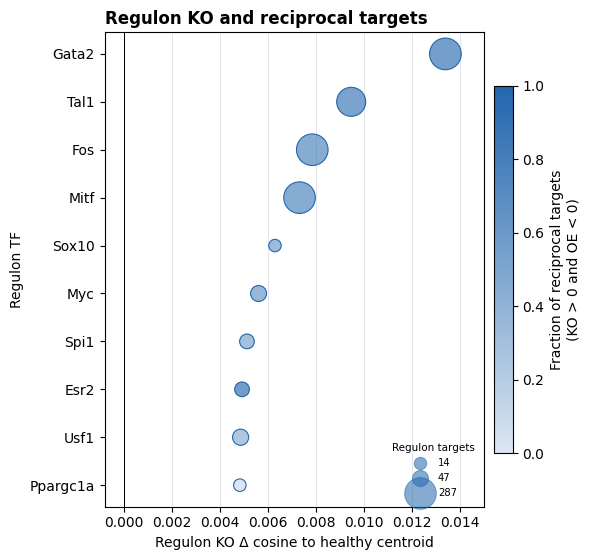

In [5]:
(fig, ax) = plt.subplots(figsize=(6.0, 5.7))
top_tf = regulon_concordance.query('delta_regulon_ko > 0').sort_values('delta_regulon_ko', ascending=False).drop_duplicates('tf_symbol').head(10).sort_values('delta_regulon_ko').copy()
top_tf['fraction_bidirectional_targets'] = pd.to_numeric(top_tf['fraction_bidirectional_targets'], errors='coerce').fillna(0.0).clip(0.0, 1.0)
top_tf['regulon_size'] = pd.to_numeric(top_tf['n_targets_in_pair'], errors='coerce').fillna(0).clip(lower=1)
top_tf.to_csv(OUT_DIR / 'depression_regulon_ko_bubble_plot_data.csv', index=False)
regulon_sizes = top_tf['regulon_size'].to_numpy(dtype=float)
size_min = float(regulon_sizes.min())
size_max = float(regulon_sizes.max())

def map_bubble_area(values, area_min=80, area_max=520):
    values = np.asarray(values, dtype=float)
    if size_max <= size_min:
        return np.full(values.shape, (area_min + area_max) / 2)
    return area_min + (values - size_min) / (size_max - size_min) * (area_max - area_min)
bubble_areas = map_bubble_area(regulon_sizes)
y_positions = np.arange(len(top_tf))
blue_alpha_cmap = LinearSegmentedColormap.from_list('blue_concordance', [to_rgba(BLUE, 0.16), to_rgba(BLUE, 1.0)])
bubble = ax.scatter(top_tf['delta_regulon_ko'], y_positions, s=bubble_areas, c=top_tf['fraction_bidirectional_targets'], cmap=blue_alpha_cmap, norm=Normalize(vmin=0, vmax=1), edgecolor=BLUE, linewidth=0.8, zorder=3)
ax.axvline(0, color='black', linewidth=0.75)
x_values = top_tf['delta_regulon_ko'].to_numpy(dtype=float)
xmin = min(0.0, float(np.nanmin(x_values)))
xmax = max(0.0, float(np.nanmax(x_values)))
xspan = max(xmax - xmin, 0.0001)
ax.set_xlim(xmin - B_X_PAD_FRACTION * xspan, xmax + B_X_PAD_FRACTION * xspan)
ax.set_yticks(y_positions)
ax.set_yticklabels(top_tf['tf_symbol'])
ax.set_xlabel('Regulon KO Δ cosine to healthy centroid')
ax.set_ylabel('Regulon TF')
ax.set_title('Regulon KO and reciprocal targets', loc='left', fontweight='bold')
ax.grid(axis='x', color=GRID, linewidth=0.55)
ax.grid(axis='y', visible=False)
colorbar = fig.colorbar(bubble, ax=ax, fraction=0.045, pad=0.025)
colorbar.set_label('Fraction of reciprocal targets\n(KO > 0 and OE < 0)')
size_examples = np.unique(np.rint(np.quantile(regulon_sizes, [0.0, 0.5, 1.0])).astype(int))
size_handles = [ax.scatter([], [], s=float(map_bubble_area([value])[0]), facecolor=BLUE, edgecolor=BLUE, alpha=0.55, linewidth=0.7, label=f'{value}') for value in size_examples]
ax.legend(handles=size_handles, title='Regulon targets', frameon=False, fontsize=7.2, title_fontsize=7.5, loc='lower right')
ax.set_xlim(xmin - .06*xspan, xmax + .12*xspan)
save_panel(fig, 'Fig5_C_regulon_KO')

## D. Five-TF target network

IMPORTANT_LABELS_FOUND ['Aif1', 'Csf1r', 'Erc2', 'Fcer1g', 'Kalrn', 'Mef2c', 'Nfkb1', 'Nrcam', 'Nrg3', 'Pdgfra', 'Plp1', 'Ppp3ca', 'Ptgds', 'Ptk2b', 'Ret', 'Slc1a3', 'Tlr4']
IMPORTANT_LABELS_MISSING []
TARGET_LABELS ['Aif1', 'Csf1r', 'Erc2', 'Fcer1g', 'Kalrn', 'Mef2c', 'Nfkb1', 'Nrcam', 'Nrg3', 'Pdgfra', 'Plp1', 'Ppp3ca', 'Ptgds', 'Ptk2b', 'Ret', 'Slc1a3', 'Tlr4']


/tmp/ipykernel_3861236/4193481588.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


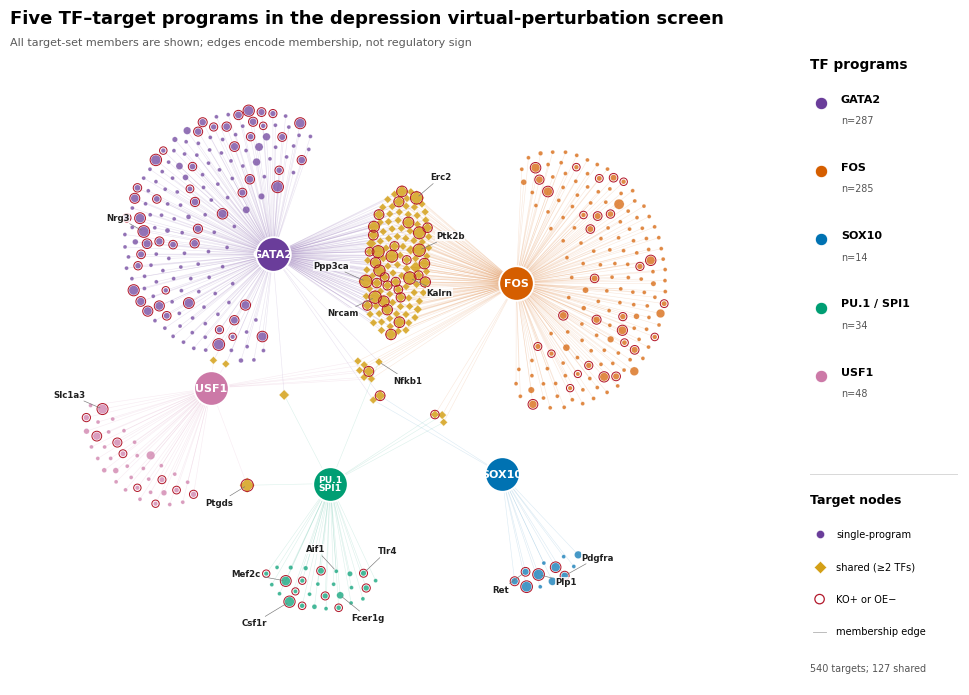

In [8]:
from collections import defaultdict
from io import BytesIO
import networkx as nx
from IPython.display import Image as IPythonImage
from matplotlib.collections import LineCollection
FIVE_TF_SPECS = [{'tf_symbol': 'Gata2', 'display': 'GATA2', 'color': '#6A3D9A'}, {'tf_symbol': 'Fos', 'display': 'FOS', 'color': '#D55E00'}, {'tf_symbol': 'Sox10', 'display': 'SOX10', 'color': '#0072B2'}, {'tf_symbol': 'Spi1', 'display': 'PU.1 / SPI1', 'color': '#009E73'}, {'tf_symbol': 'Usf1', 'display': 'USF1', 'color': '#CC79A7'}]
FIVE_TF_ORDER = [spec['tf_symbol'] for spec in FIVE_TF_SPECS]
FIVE_TF_COLORS = {spec['tf_symbol']: spec['color'] for spec in FIVE_TF_SPECS}
FIVE_TF_DISPLAY = {spec['tf_symbol']: spec['display'] for spec in FIVE_TF_SPECS}
FIVE_TF_SHARED_COLOR = '#D4A017'
FIVE_TF_RED = '#B2182B'
FIVE_TF_NETWORK_DIR = OUT_DIR / 'target_linked' / 'five_tf_integrated_network'
FIVE_TF_NETWORK_DIR.mkdir(parents=True, exist_ok=True)
program_rows = []
target_membership = defaultdict(list)
for spec in FIVE_TF_SPECS:
    tf_symbol = spec['tf_symbol']
    candidates = regulon.loc[regulon['tf_symbol'].astype(str).eq(tf_symbol)].sort_values('delta_cosine', ascending=False)
    row = candidates.iloc[0]
    targets = [gene_id for gene_id in str(row['target_ensembl_in_model']).split(';') if gene_id and gene_id != 'nan']
    targets = list(dict.fromkeys(targets))
    tf_ensembl = str(row.get('tf_ensembl', ''))
    program_rows.append({'tf_symbol': tf_symbol, 'tf_display': spec['display'], 'regulon_id': str(row['regulon_id']), 'collection': str(row['collection']), 'delta_target_set_ko': float(row['delta_cosine']), 'n_targets_in_selected_set': int(len(targets)), 'tf_ensembl': tf_ensembl, 'tf_in_target_set': bool(tf_ensembl in targets)})
    for gene_id in targets:
        target_membership[gene_id].append(tf_symbol)
five_tf_programs = pd.DataFrame(program_rows).set_index('tf_symbol', drop=False)
FIVE_TF_OE25_PATH = TUTORIAL / 'data/03_depression/depression_tf_fixed_oe_cross_modal_summary.csv'
five_tf_oe25 = pd.read_csv(FIVE_TF_OE25_PATH).set_index('tf_symbol')
for tf_symbol in FIVE_TF_ORDER:
    five_tf_programs.loc[tf_symbol, 'delta_tf_oe25'] = float(five_tf_oe25.loc[tf_symbol, 'fixed_floor_25'])

def _five_tf_gene_symbol(gene_id):
    if gene_id in gene_scan.index:
        return str(gene_scan.loc[gene_id, 'gene_symbol'])
    if gene_id in adata_pair.var_names and 'gene_symbol' in adata_pair.var.columns:
        return str(adata_pair.var.loc[gene_id, 'gene_symbol'])
    return str(gene_id)
target_rows = []
for (gene_id, memberships) in sorted(target_membership.items()):
    memberships = [tf for tf in FIVE_TF_ORDER if tf in memberships]
    if gene_id in gene_scan.index:
        scan = gene_scan.loc[gene_id]
        delta_ko = float(scan['delta_gene_ko'])
        delta_oe = float(scan['delta_gene_oe5x'])
        strength = abs(delta_ko) + abs(delta_oe)
        directional_support = bool(delta_ko > 0 or delta_oe < 0)
    else:
        delta_ko = np.nan
        delta_oe = np.nan
        strength = 0.0
        directional_support = False
    target_rows.append({'gene_ensembl': gene_id, 'gene_symbol': _five_tf_gene_symbol(gene_id), 'program_memberships': ';'.join(memberships), 'n_programs': int(len(memberships)), 'is_shared_target': bool(len(memberships) >= 2), 'delta_gene_ko': delta_ko, 'delta_gene_oe5x': delta_oe, 'gene_perturbation_strength': float(strength), 'gene_ko_or_oe_support': directional_support})
five_tf_targets = pd.DataFrame(target_rows).set_index('gene_ensembl', drop=False)
graph = nx.Graph()
tf_nodes = {tf: f'TF::{tf}' for tf in FIVE_TF_ORDER}
for (tf_symbol, node_id) in tf_nodes.items():
    graph.add_node(node_id, node_type='tf', tf_symbol=tf_symbol)
for (gene_id, row) in five_tf_targets.iterrows():
    graph.add_node(gene_id, node_type='target')
    for tf_symbol in row['program_memberships'].split(';'):
        graph.add_edge(tf_nodes[tf_symbol], gene_id, tf_symbol=tf_symbol)
anchor_coordinates = {'Gata2': np.array([-1.3, 1.05]), 'Fos': np.array([1.25, 0.75]), 'Sox10': np.array([1.1, -1.25]), 'Spi1': np.array([-0.7, -1.35]), 'Usf1': np.array([-1.95, -0.35])}
initial_pos = {tf_nodes[tf_symbol]: coordinates.copy() for (tf_symbol, coordinates) in anchor_coordinates.items()}
rng = np.random.default_rng(42)
for (gene_id, row) in five_tf_targets.sort_index().iterrows():
    memberships = row['program_memberships'].split(';')
    anchors = np.vstack([initial_pos[tf_nodes[tf]] for tf in memberships])
    anchor_mean = anchors.mean(axis=0)
    if len(memberships) == 1:
        center = 0.92 * anchor_mean
        jitter = rng.normal(0.0, 0.4, size=2)
    else:
        center = 0.7 * anchor_mean
        jitter = rng.normal(0.0, 0.22, size=2)
    initial_pos[gene_id] = center + jitter
layout = nx.spring_layout(graph, pos=initial_pos, fixed=list(tf_nodes.values()), k=0.22, iterations=650, threshold=0.0001, weight=None, seed=42, scale=None)
for gene_id in five_tf_targets.index:
    five_tf_targets.loc[gene_id, 'network_x'] = float(layout[gene_id][0])
    five_tf_targets.loc[gene_id, 'network_y'] = float(layout[gene_id][1])
IMPORTANT_TARGET_SYMBOLS = {'Nrg3', 'Ptk2b', 'Ppp3ca', 'Erc2', 'Kalrn', 'Nrcam', 'Plp1', 'Pdgfra', 'Ret', 'Ptgds', 'Csf1r', 'Mef2c', 'Slc1a3', 'Aif1', 'Fcer1g', 'Tlr4', 'Nfkb1'}
label_genes = set(five_tf_targets.loc[five_tf_targets['gene_symbol'].isin(IMPORTANT_TARGET_SYMBOLS)].index)
found_important_symbols = set(five_tf_targets.loc[list(label_genes), 'gene_symbol']) if label_genes else set()
print('IMPORTANT_LABELS_FOUND', sorted(found_important_symbols))
print('IMPORTANT_LABELS_MISSING', sorted(IMPORTANT_TARGET_SYMBOLS.difference(found_important_symbols)))
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
strength_limit = max(float(np.quantile(five_tf_targets['gene_perturbation_strength'], 0.98)), 1e-08)
scaled_strength = np.clip(five_tf_targets['gene_perturbation_strength'] / strength_limit, 0, 1)
five_tf_targets['plot_size'] = 8.0 + 45.0 * np.sqrt(scaled_strength)
five_tf_targets.loc[five_tf_targets['is_shared_target'], 'plot_size'] += 8.0
fig = plt.figure(figsize=(10.4, 7.15), facecolor='white')
grid = fig.add_gridspec(1, 2, width_ratios=[5.35, 0.95], wspace=0.005)
ax = fig.add_subplot(grid[0, 0])
key_ax = fig.add_subplot(grid[0, 1])
for tf_symbol in FIVE_TF_ORDER:
    hub = tf_nodes[tf_symbol]
    segments = [[layout[hub], layout[target]] for target in graph.neighbors(hub)]
    ax.add_collection(LineCollection(segments, colors=FIVE_TF_COLORS[tf_symbol], linewidths=0.42, alpha=0.14, zorder=1))
for tf_symbol in FIVE_TF_ORDER:
    frame = five_tf_targets.loc[(five_tf_targets['n_programs'] == 1) & five_tf_targets['program_memberships'].eq(tf_symbol)]
    ax.scatter(frame['network_x'], frame['network_y'], s=frame['plot_size'], color=FIVE_TF_COLORS[tf_symbol], alpha=0.72, edgecolor='white', linewidth=0.22, zorder=2)
shared = five_tf_targets.loc[five_tf_targets['is_shared_target']]
ax.scatter(shared['network_x'], shared['network_y'], s=shared['plot_size'], color=FIVE_TF_SHARED_COLOR, marker='D', alpha=0.84, edgecolor='white', linewidth=0.28, zorder=3)
directional_support = five_tf_targets.loc[five_tf_targets['gene_ko_or_oe_support']]
ax.scatter(directional_support['network_x'], directional_support['network_y'], s=directional_support['plot_size'] + 18, facecolor='none', edgecolor=FIVE_TF_RED, linewidth=0.72, zorder=4)
for tf_symbol in FIVE_TF_ORDER:
    (x, y) = layout[tf_nodes[tf_symbol]]
    ax.scatter([x], [y], s=620, marker='o', facecolor=FIVE_TF_COLORS[tf_symbol], edgecolor='white', linewidth=1.35, zorder=8)
    hub_display = 'PU.1\nSPI1' if tf_symbol == 'Spi1' else FIVE_TF_DISPLAY[tf_symbol]
    hub_fontsize = 6.6 if tf_symbol == 'Spi1' else 8.0
    ax.text(x, y, hub_display, ha='center', va='center', fontsize=hub_fontsize, color='white', fontweight='bold', linespacing=0.92, zorder=9)
IMPORTANT_LABEL_OFFSETS = {'Nrg3': (-10, 7), 'Erc2': (10, 12), 'Ptk2b': (12, 7), 'Kalrn': (12, -7), 'Ppp3ca': (-12, 8), 'Nrcam': (-12, -8), 'Nfkb1': (10, -10), 'Pdgfra': (12, 10), 'Plp1': (12, -2), 'Ret': (-12, -10), 'Aif1': (-8, 13), 'Csf1r': (-16, -12), 'Fcer1g': (8, -13), 'Mef2c': (-18, 2), 'Tlr4': (10, 13), 'Ptgds': (-10, -9), 'Slc1a3': (-12, 7)}
for gene_id in sorted(label_genes):
    row = five_tf_targets.loc[gene_id]
    symbol = str(row['gene_symbol'])
    offset = IMPORTANT_LABEL_OFFSETS[symbol]
    ax.annotate(symbol, xy=(row['network_x'], row['network_y']), xytext=offset, textcoords='offset points', ha='left' if offset[0] >= 0 else 'right', va='bottom' if offset[1] >= 0 else 'top', fontsize=6.2, color='#202020', fontweight='bold', bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82, 'pad': 0.35}, arrowprops={'arrowstyle': '-', 'color': '#777777', 'lw': 0.45}, zorder=10)
print('TARGET_LABELS', sorted(IMPORTANT_TARGET_SYMBOLS))
all_xy = np.vstack([np.asarray(value) for value in layout.values()])
x_pad = 0.8
y_pad = 0.8
ax.set_xlim(all_xy[:, 0].min() - x_pad, all_xy[:, 0].max() + x_pad)
ax.set_ylim(all_xy[:, 1].min() - y_pad, all_xy[:, 1].max() + y_pad)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Five TF–target programs in the depression virtual-perturbation screen', loc='left', fontsize=13.0, fontweight='bold', pad=8)
ax.text(0.0, 0.995, 'All target-set members are shown; edges encode membership, not regulatory sign', transform=ax.transAxes, ha='left', va='top', fontsize=8.0, color='#5B5B5B')
key_ax.set_xlim(0, 1)
key_ax.set_ylim(0, 1)
key_ax.axis('off')
key_ax.text(0.02, 0.965, 'TF programs', fontsize=9.8, fontweight='bold', va='top')
key_y = 0.895
for tf_symbol in FIVE_TF_ORDER:
    program = five_tf_programs.loc[tf_symbol]
    key_ax.scatter([0.09], [key_y], s=82, color=FIVE_TF_COLORS[tf_symbol], edgecolor='white', linewidth=0.75)
    key_ax.text(0.22, key_y + 0.006, FIVE_TF_DISPLAY[tf_symbol], fontsize=8.0, fontweight='bold', va='center')
    key_ax.text(0.22, key_y - 0.027, f"n={int(program['n_targets_in_selected_set'])}", fontsize=6.9, color='#555555', va='center')
    key_y -= 0.105
key_ax.plot([0.02, 0.98], [0.325, 0.325], color='#D8D8D8', lw=0.7)
key_ax.text(0.02, 0.295, 'Target nodes', fontsize=9.0, fontweight='bold', va='top')
key_ax.scatter([0.08], [0.232], s=34, color=FIVE_TF_COLORS['Gata2'], edgecolor='white', lw=0.3)
key_ax.text(0.19, 0.232, 'single-program', fontsize=7.1, va='center')
key_ax.scatter([0.08], [0.182], s=40, color=FIVE_TF_SHARED_COLOR, marker='D', edgecolor='white', lw=0.3)
key_ax.text(0.19, 0.182, 'shared (≥2 TFs)', fontsize=7.1, va='center')
key_ax.scatter([0.08], [0.132], s=46, facecolor='none', edgecolor=FIVE_TF_RED, lw=0.9)
key_ax.text(0.19, 0.132, 'KO+ or OE−', fontsize=7.1, va='center')
key_ax.plot([0.035, 0.125], [0.082, 0.082], color='#888888', lw=0.6, alpha=0.65)
key_ax.text(0.19, 0.082, 'membership edge', fontsize=7.1, va='center')
key_ax.text(0.02, 0.018, f"{len(five_tf_targets)} targets; {int(five_tf_targets['is_shared_target'].sum())} shared", fontsize=6.9, color='#555555', va='bottom')
fig.subplots_adjust(left=0.018, right=0.992, top=0.935, bottom=0.025)
edge_rows = []
for (gene_id, row) in five_tf_targets.iterrows():
    for tf_symbol in row['program_memberships'].split(';'):
        edge_rows.append({'tf_symbol': tf_symbol, 'tf_display': FIVE_TF_DISPLAY[tf_symbol], 'regulon_id': five_tf_programs.loc[tf_symbol, 'regulon_id'], 'gene_ensembl': gene_id, 'gene_symbol': row['gene_symbol']})
five_tf_edges = pd.DataFrame(edge_rows)
five_tf_programs.to_csv(FIVE_TF_NETWORK_DIR / 'five_tf_program_summary.csv', index=False)
five_tf_targets.to_csv(FIVE_TF_NETWORK_DIR / 'five_tf_target_nodes.csv', index=False)
five_tf_edges.to_csv(FIVE_TF_NETWORK_DIR / 'five_tf_target_membership_edges.csv', index=False)
save_panel(fig, 'Fig5_D_five_TF_network')